In [1]:
import pandas as pd

In [2]:
vg_data = pd.read_csv('vgsales.csv')
starbucks_data = pd.read_csv('directory.csv')

In [7]:
vg_data['Year'] = vg_data['Year'].replace('N/A', None)
vg_data = vg_data.dropna(subset=['Year'])
vg_data['Year'] = vg_data['Year'].astype(int)

In [8]:
vg_encoded = pd.get_dummies(vg_data, columns=['Genre'], drop_first=True)
starbucks_encoded = pd.get_dummies(starbucks_data, columns=['Ownership Type'], drop_first=True)

print("Video Game Data Cleaned Shape:", vg_encoded.shape)
print("Starbucks Data Cleaned Shape:", starbucks_encoded.shape)

Video Game Data Cleaned Shape: (16327, 21)
Starbucks Data Cleaned Shape: (25600, 15)


In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

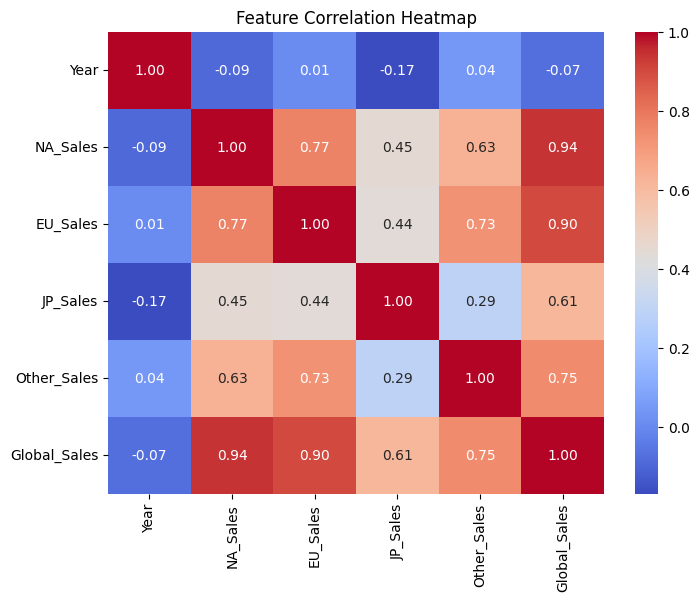

In [14]:
#  1. FEATURE SELECTION (Correlation Heatmap)
numerical_cols = ['Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
correlation_matrix = vg_data[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [18]:
# 2. TRAIN-TEST SPLIT (Chronological Sequence)
vg_encoded = vg_encoded.sort_values(by='Year')

train_df = vg_encoded[vg_encoded['Year'] <= 2012]
test_df = vg_encoded[vg_encoded['Year'] > 2012]

In [19]:
X_train = train_df.drop(columns=['Rank', 'Name', 'Platform', 'Publisher', 'Global_Sales'])
y_train = train_df['Global_Sales']
X_test = test_df.drop(columns=['Rank', 'Name', 'Platform', 'Publisher', 'Global_Sales'])
y_test = test_df['Global_Sales']

In [20]:
# 3. BASELINE MODELING (Linear Regression)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [21]:
# 4. MODEL EVALUATION
lr_predictions = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

In [22]:
print(f"Linear Regression MAE: {lr_mae:.4f}")
print(f"Linear Regression RMSE: {lr_rmse:.4f}")

Linear Regression MAE: 0.0026
Linear Regression RMSE: 0.0049


In [23]:
from sklearn.ensemble import RandomForestRegressor

In [24]:
# 1. CREATING A LAG-LIKE FEATURE
X_train['Regional_Demand_Momentum'] = X_train[['NA_Sales', 'EU_Sales', 'JP_Sales']].mean(axis=1)
X_test['Regional_Demand_Momentum'] = X_test[['NA_Sales', 'EU_Sales', 'JP_Sales']].mean(axis=1)

In [25]:
# 2. ADVANCED MODELING (Random Forest)
rf_model = RandomForestRegressor(n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, random_state=42)

In [26]:
# 3. MODEL EVALUATION & COMPARISON
rf_predictions = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

In [27]:
print(f"Random Forest MAE: {rf_mae:.4f}")
print(f"Random Forest RMSE: {rf_rmse:.4f}")

Random Forest MAE: 0.0101
Random Forest RMSE: 0.0858


In [28]:
# Visualizing which model performed better
print("\n--- Model Comparison Performance ---")
print(f"Linear Regression RMSE: {lr_rmse:.4f}")
print(f"Random Forest Regressor RMSE: {rf_rmse:.4f}")


--- Model Comparison Performance ---
Linear Regression RMSE: 0.0049
Random Forest Regressor RMSE: 0.0858
